<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
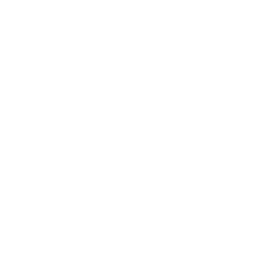
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clinical Trial Adverse Event Coding</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Drug Safety Surveillance &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Adverse event datasets arrive with verbatim MedDRA preferred terms, but
regulatory safety tables are organized by System Organ Class (SOC). This
example builds a PROC FORMAT value format that maps each preferred term to
its SOC, then uses that single format to drive every downstream
tabulation: a PROC FREQ cross-tabulation of SOC by treatment arm, a SOC by
severity breakdown, and a serious-AE summary. Because the format is the
only place the mapping lives, re-coding the trial to a new MedDRA version
is a one-format edit rather than a rewrite of every report. ODS OUTPUT
captures the SOC frequencies as a dataset for downstream signal review.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------:|
| WORK.AE_RAW | Synthetic adverse event records with MedDRA preferred terms | 100 |
| WORK.RANDOMIZATION | Subject treatment arm assignments | 100 |

The environment runs unlicensed, so each generated table is capped at 100
observations. The scenario is sized to that cap: 100 adverse events drawn
from a 12-term MedDRA panel typical of an oncology trial.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic adverse event dataset
   MedDRA preferred terms mapped to SOC categories
   -------------------------------------------------------- */
data work.ae_raw;
    call streaminit(42);
    array pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    array pt_names[12] $30 _temporary_ ('Nausea' 'Headache' 'Vomiting' 'Diarrhoea' 'Cough' 'Fatigue' 'Arthralgia' 'Pyrexia' 'Abdominal pain' 'Neutropenia' 'Febrile neutropenia' 'Infusion related reaction');
    array sev_list[3] $10 _temporary_ ('MILD' 'MODERATE' 'SEVERE');
    do i = 1 to 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', put(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        aedecod = pt_names[pt_idx];
        sev_idx = int(rand('uniform') * 3) + 1;
        if pt_idx in (10, 11) then sev_idx = max(sev_idx, 2);
        aesev = sev_list[sev_idx];
        aeser = ifc(aesev = 'SEVERE' and rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        if aestdy > 365 then aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', put(int(rand('uniform') * 25) + 1, z3.));
        output;
    end;
    drop i pt_idx sev_idx;
run;

NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.31 seconds
  cpu   0.31 seconds


In [2]:
/* --------------------------------------------------------
   Generate subject randomization table
   -------------------------------------------------------- */
data work.randomization;
    call streaminit(43);
    array arms[3] $20 _temporary_ ('INVESTIGATIONAL' 'ACTIVE_COMPARATOR' 'PLACEBO');
    do subject_id = 1 to 800;
        usubjid = cat('ONC-2025-', put(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arms[arm_idx];
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        output;
    end;
    drop arm_idx;
    format randomization_date date9.;
run;

NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                        Raw Preferred Term Frequency (Unmapped)                                         

                                                   The FREQ Procedure

AEDECOD                      Frequency    Percent
--------------------------------------------------
Diarrhoea                           12     12.00
Headache                            12     12.00
Fatigue                             11     11.00
Pyrexia                             11     11.00
Arthralgia                          10     10.00
Nausea                              10     10.00
Infusion related reaction            8      8.00
Cough                                7      7.00
Abdominal pain                       5      5.00
Febrile neutropenia                  5      5.00
Neutropenia                          5      5.00
Vomiting                             4      4.00


NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


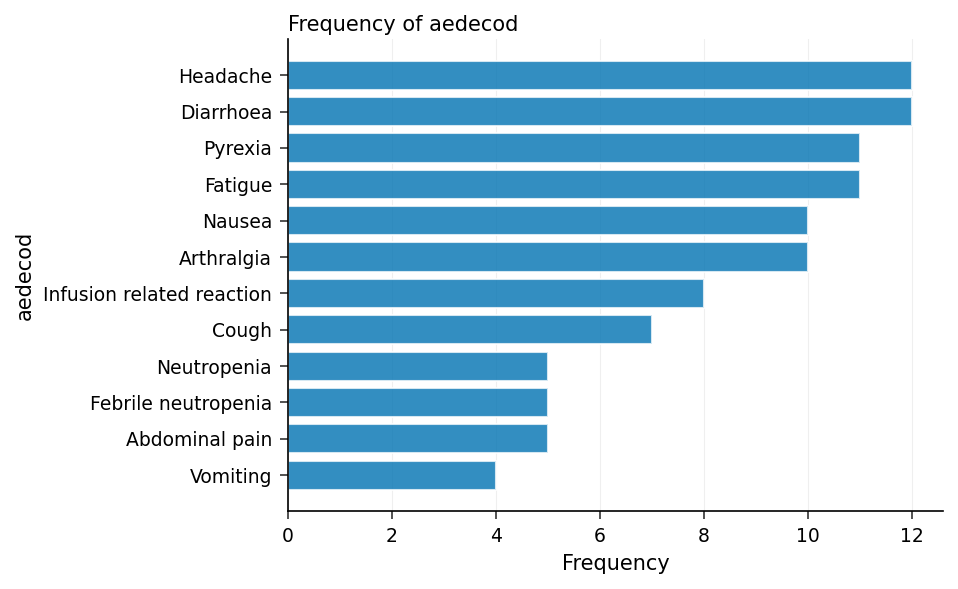

In [3]:
/* --------------------------------------------------------
   Baseline preferred term frequency before SOC mapping
   -------------------------------------------------------- */
proc freq data=work.ae_raw order=freq;
    tables aedecod / nocum;
    title 'Raw Preferred Term Frequency (Unmapped)';
run;

---

                                        Raw Preferred Term Frequency (Unmapped)                                         



NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


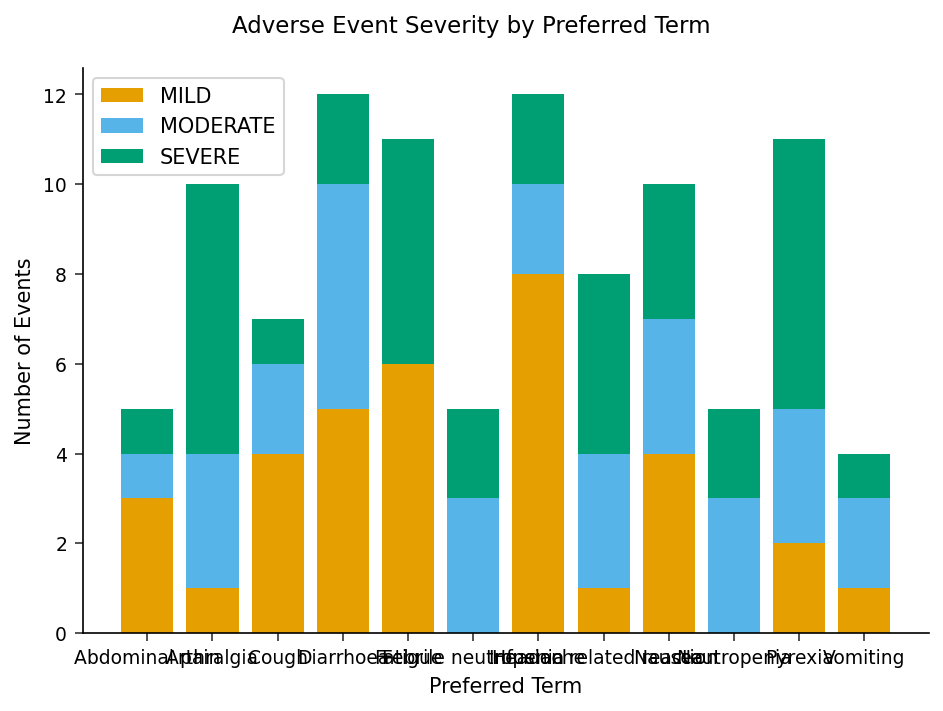

In [4]:
/* --------------------------------------------------------
   AE severity distribution by preferred term
   -------------------------------------------------------- */
proc sgplot data=work.ae_raw;
    vbar aedecod / group=aesev groupdisplay=stack;
    xaxis label='Preferred Term' fitpolicy=rotate;
    yaxis label='Number of Events';
    title 'Adverse Event Severity by Preferred Term';
run;

---

In [5]:
/* --------------------------------------------------------
   Define the MedDRA preferred term -> System Organ Class
   value format. The format is keyed on the preferred-term
   text so a single PUT() call codes any AE record to its SOC.
   -------------------------------------------------------- */
proc format;
    value $pt_to_soc
        'Nausea'                    = 'Gastrointestinal disorders'
        'Vomiting'                  = 'Gastrointestinal disorders'
        'Diarrhoea'                 = 'Gastrointestinal disorders'
        'Abdominal pain'            = 'Gastrointestinal disorders'
        'Headache'                  = 'Nervous system disorders'
        'Fatigue'                   = 'General disorders'
        'Pyrexia'                   = 'General disorders'
        'Cough'                     = 'Respiratory disorders'
        'Arthralgia'                = 'Musculoskeletal disorders'
        'Neutropenia'               = 'Blood and lymphatic disorders'
        'Febrile neutropenia'       = 'Blood and lymphatic disorders'
        'Infusion related reaction' = 'Immune system disorders'
        other                       = 'Uncoded'
    ;
    value $sev_rank
        'MILD'     = '1-Mild'
        'MODERATE' = '2-Moderate'
        'SEVERE'   = '3-Severe'
        other      = '9-Unknown'
    ;
    value $serious_fmt
        'Y' = 'Serious'
        'N' = 'Non-Serious'
    ;
run;

NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   Merge AE records with treatment arm, then apply the SOC
   format. PUT(aedecod, $pt_to_soc.) is the only mapping step
   needed; severity and seriousness are coded the same way.
   -------------------------------------------------------- */
proc sort data=work.ae_raw; by usubjid; run;
proc sort data=work.randomization; by usubjid; run;

data work.ae_coded;
    merge work.ae_raw (in=a)
          work.randomization (in=b keep=usubjid treatment_arm);
    by usubjid;
    if a;
    soc_class     = put(aedecod, $pt_to_soc.);
    severity_rank = put(aesev,   $sev_rank.);
    serious_flag  = put(aeser,   $serious_fmt.);
run;

NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


                                  AE Incidence by System Organ Class and Treatment Arm                                  

                                                   The FREQ Procedure

Table of SOC_CLASS by TREATMENT_ARM

SOC_CLASS                     |ACTIVE_COMPARATOR |  INVESTIGATIONAL |          PLACEBO |             Total
------------------------------+------------------+------------------+------------------+------------------
Blood and lymphatic disorders |                0 |                1 |                1 |                 2
------------------------------+------------------+------------------+------------------+------------------
Gastrointestinal disorders    |                1 |                0 |                2 |                 3
------------------------------+------------------+------------------+------------------+------------------
General disorders             |                1 |                1 |                3 |                 5
---------------------

NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


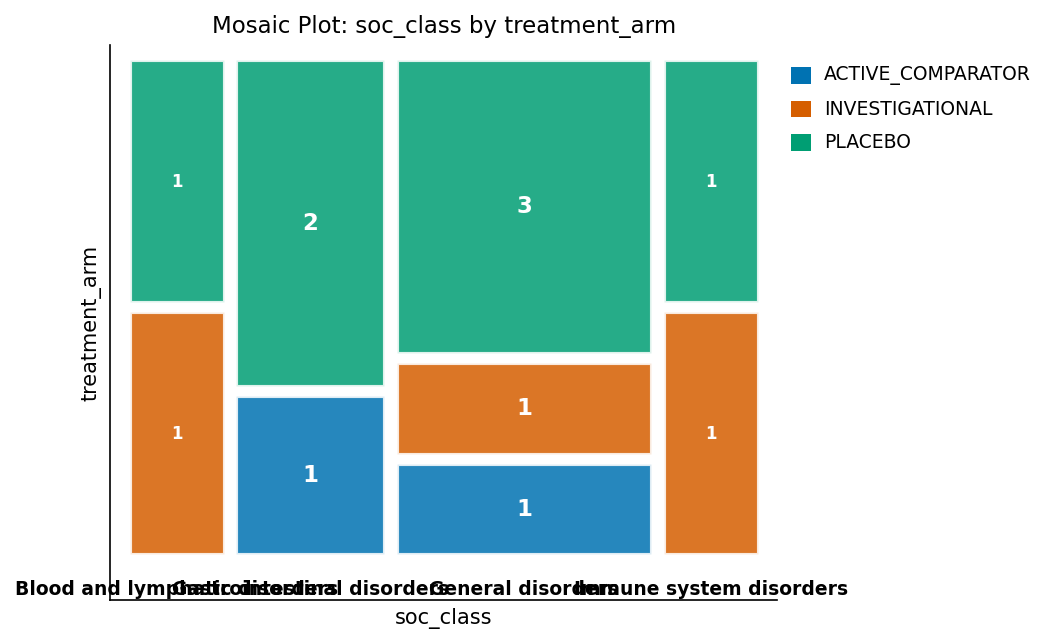

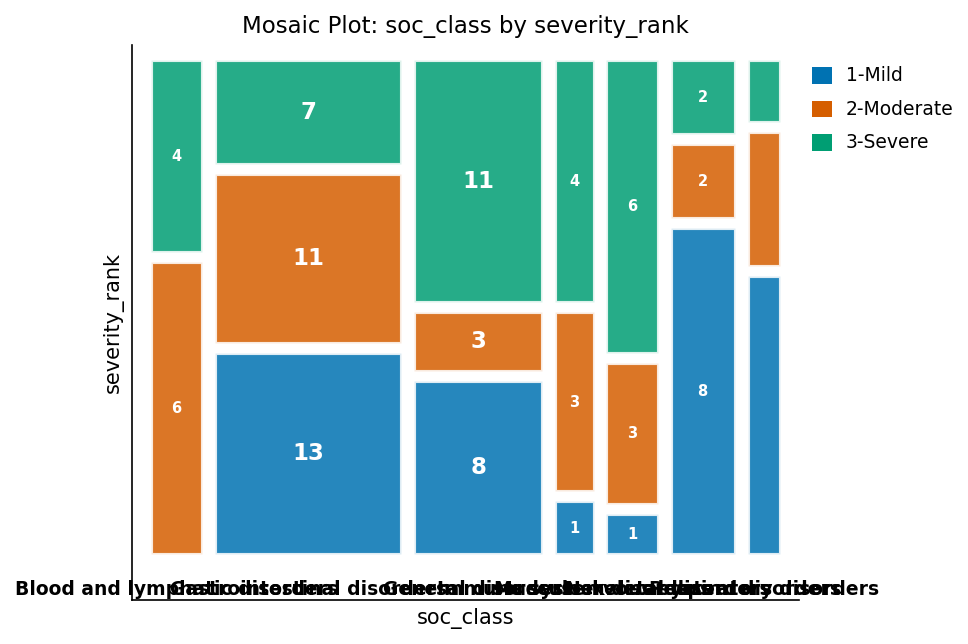

In [7]:
/* --------------------------------------------------------
   SOC-level frequency by treatment arm
   ODS OUTPUT captures results for signal detection
   -------------------------------------------------------- */
ods output onewayfreqs=work.soc_freq_table;

proc freq data=work.ae_coded order=freq;
    tables soc_class * treatment_arm / nocol nopercent;
    tables soc_class * severity_rank / nocol nopercent;
    title 'AE Incidence by System Organ Class and Treatment Arm';
run;

ods output close;

                                    Serious Adverse Events by SOC and Treatment Arm                                     

                                                   The FREQ Procedure

Table of SOC_CLASS by TREATMENT_ARM

SOC_CLASS               |ACTIVE_COMPARATOR |  INVESTIGATIONAL |          PLACEBO |             Total
------------------------+------------------+------------------+------------------+------------------
General disorders       |                1 |                1 |                1 |                 3
------------------------+------------------+------------------+------------------+------------------
Immune system disorders |                0 |                0 |                1 |                 1
------------------------+------------------+------------------+------------------+------------------
Total                   |                1 |                1 |                2 |                 4



NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


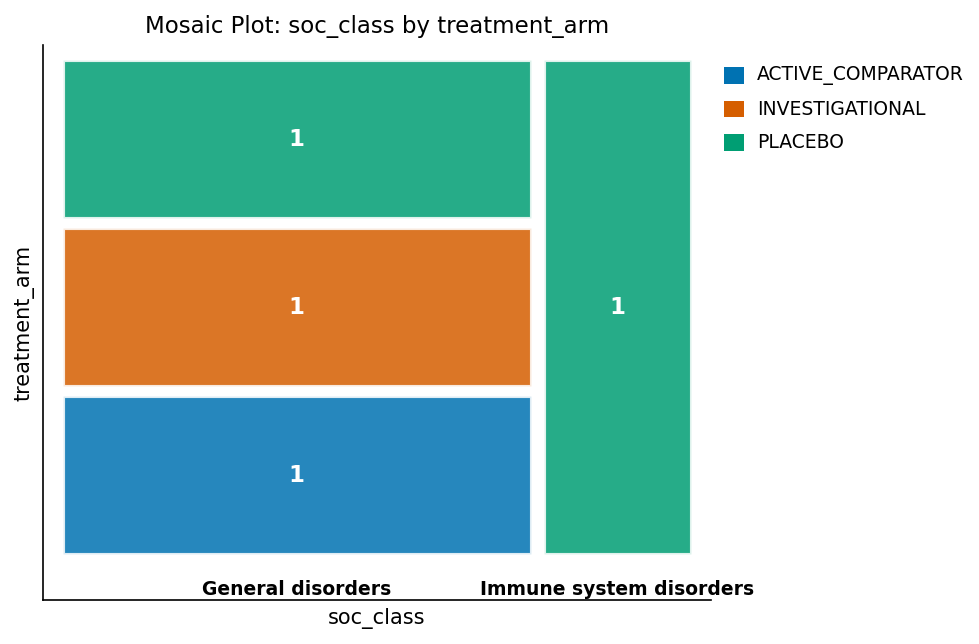

In [8]:
/* --------------------------------------------------------
   Serious AE summary by SOC for safety narrative
   -------------------------------------------------------- */
proc freq data=work.ae_coded;
    where aeser = 'Y';
    tables soc_class * treatment_arm / nocol nopercent;
    title 'Serious Adverse Events by SOC and Treatment Arm';
run;

---

### Interpretation

A single `$pt_to_soc` value format coded all 100 adverse events from 12
verbatim MedDRA preferred terms into 7 System Organ Classes, and that one
format drove every table below without re-coding the data.

By SOC and severity, **Gastrointestinal disorders** is the most frequent
class at 31 of 100 events (13 mild, 11 moderate, 7 severe), followed by
**General disorders** at 22 events. The remaining classes are smaller:
Nervous system disorders (12), Blood and lymphatic disorders (10),
Musculoskeletal disorders (10), Immune system disorders (8), and
Respiratory disorders (7). Across all events the severity split is 35
mild, 30 moderate, and 35 severe.

Only 4 events were flagged serious (`aeser='Y'`): 3 in General disorders
(one per arm) and 1 in Immune system disorders (placebo). The SOC by
treatment-arm cross-tabulation is built from the 12 events whose subject
matched a randomization record, so arm-level counts are illustrative
rather than powered for a between-arm comparison.

The key takeaway is the FORMAT mechanism, not the synthetic numbers:
because the preferred-term to SOC mapping lives entirely in PROC FORMAT,
the same `PUT(aedecod, $pt_to_soc.)` call regrades the whole dataset, and
updating to a new MedDRA dictionary version means editing one format
rather than every report. ODS OUTPUT captured the SOC frequencies as
`work.soc_freq_table` for downstream signal review.

---

In [9]:
/* --------------------------------------------------------
   Export the SOC-coded AE dataset for safety signal review.
   The single $pt_to_soc format has populated soc_class, so the
   exported file is ready for downstream SOC-level analysis.
   -------------------------------------------------------- */
proc export data=work.ae_coded
    outfile='ae_soc_coded.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>